In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/online_retail_final.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceYear,InvoiceDay,InvoiceHour,IsWeekend,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,8,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,8,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,8,False,20.34


In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     392692 non-null  int64  
 1   StockCode     392692 non-null  object 
 2   Description   392692 non-null  object 
 3   Quantity      392692 non-null  int64  
 4   InvoiceDate   392692 non-null  object 
 5   UnitPrice     392692 non-null  float64
 6   CustomerID    392692 non-null  int64  
 7   Country       392692 non-null  object 
 8   Revenue       392692 non-null  float64
 9   InvoiceMonth  392692 non-null  object 
 10  InvoiceYear   392692 non-null  int64  
 11  InvoiceDay    392692 non-null  object 
 12  InvoiceHour   392692 non-null  int64  
 13  IsWeekend     392692 non-null  bool   
 14  TotalPrice    392692 non-null  float64
dtypes: bool(1), float64(3), int64(5), object(6)
memory usage: 42.3+ MB


,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue,InvoiceYear,InvoiceHour,TotalPrice
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500,2010.934631,12.721532,22.631500
std,13087.063759,180.492832,22.241836,1713.539549,311.099224,0.247177,2.276661,311.099224
min,536365.000000,1.000000,0.001000,12346.000000,0.001000,2010.000000,6.000000,0.001000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000,2011.000000,11.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000,2011.000000,13.000000,12.450000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000,2011.000000,14.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000,2011.000000,20.000000,168469.600000


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'InvoiceMonth',
       'InvoiceYear', 'InvoiceDay', 'InvoiceHour', 'IsWeekend', 'TotalPrice'],
      dtype='object')

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Calculate Average Order Value (AOV)

Average Order Value =
Total Revenue / Total Orders

In [6]:
total_revenue = df["TotalPrice"].sum()

total_orders = df["InvoiceNo"].nunique()

average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value,2))

Average Order Value: 479.56


Calculate Purchase Frequency
Formula
Purchase Frequency =
Total Orders / Total Customers

In [7]:
total_customers = df["CustomerID"].nunique()

purchase_frequency = total_orders / total_customers

print("Purchase Frequency:", round(purchase_frequency,2))

Purchase Frequency: 4.27


Calculate Customer Value

Formula

Customer Value =
Average Order Value × Purchase Frequency

In [8]:
customer_value = average_order_value * purchase_frequency

print("Customer Value:", round(customer_value,2))

Customer Value: 2048.69


Estimate Customer Lifespan


In [10]:
customer_lifespan = 3
print("Customer Lifespan:", customer_lifespan)


Customer Lifespan: 3


CLTV =
Customer Value × Customer Lifespan

In [11]:
cltv = customer_value * customer_lifespan

print("Estimated CLTV:", round(cltv,2))

Estimated CLTV: 6146.06


Calculate Individual Customer CLTV

In [12]:
customer_summary = df.groupby("CustomerID").agg({
    "InvoiceNo":"nunique",
    "TotalPrice":"sum"
})

customer_summary.head()

,InvoiceNo,TotalPrice
CustomerID,,
12346,1,77183.60
12347,7,4310.00
12348,4,1797.24
12349,1,1757.55
12350,1,334.40


In [13]:
customer_summary.columns = [
    "TotalOrders",
    "TotalRevenue"
]

Average Revenue per Order

In [14]:
customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalOrders"]
)

Customer CLTV

In [15]:
customer_summary["CLTV"] = (
    customer_summary["AverageOrderValue"]
    * customer_summary["TotalOrders"]
)

Sort Highest CLTV Customers

In [16]:
customer_summary = customer_summary.sort_values(
    by="CLTV",
    ascending=False
)

customer_summary.head(20)

,TotalOrders,TotalRevenue,AverageOrderValue,CLTV
CustomerID,,,,
14646,73,280206.02,3838.438630,280206.02
18102,60,259657.30,4327.621667,259657.30
17450,46,194390.79,4225.886739,194390.79
16446,2,168472.50,84236.250000,168472.50
14911,201,143711.17,714.980945,143711.17
12415,21,124914.53,5948.310952,124914.53
14156,55,117210.08,2131.092364,117210.08
17511,31,91062.38,2937.496129,91062.38
16029,63,80850.84,1283.346667,80850.84


Top 20 CLTV Bar Chart

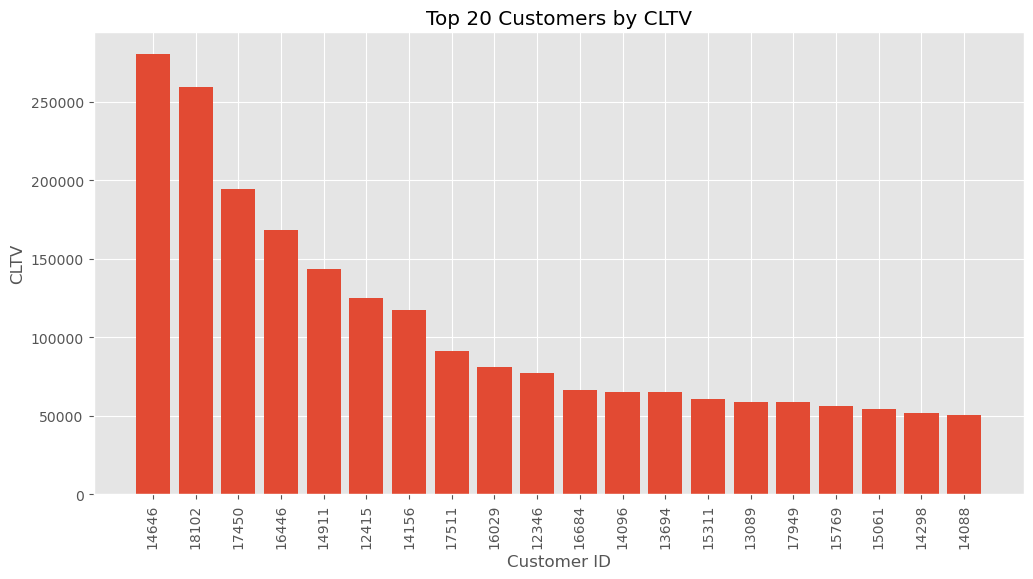

In [17]:
top20 = customer_summary.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top20.index.astype(str),
    top20["CLTV"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Customers by CLTV")

plt.xlabel("Customer ID")

plt.ylabel("CLTV")

plt.show()

CLTV Distribution

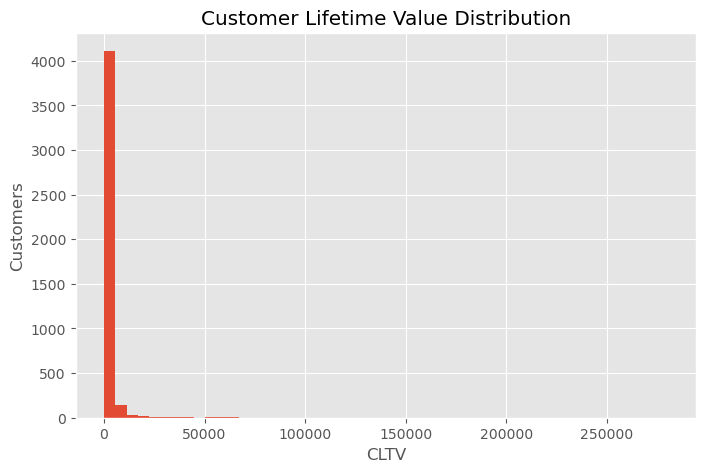

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_summary["CLTV"],
    bins=50
)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("CLTV")

plt.ylabel("Customers")

plt.show()

Customer Categories

In [19]:
customer_summary["CLTV_Level"] = pd.qcut(
    customer_summary["CLTV"],
    4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

Count CLTV Levels

In [20]:
customer_summary["CLTV_Level"].value_counts()

CLTV_Level
Low       1085
VIP       1085
Medium    1084
High      1084
Name: count, dtype: int64

Pie Chart

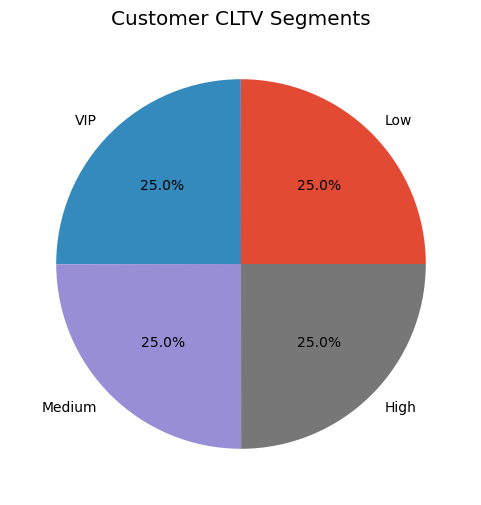

In [21]:
customer_summary["CLTV_Level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Customer CLTV Segments")

plt.show()

Save Dataset

In [22]:
customer_summary.to_csv(
    "../data/processed/cltv_data.csv"
)

# Customer Lifetime Value (CLTV) Insights

## Key Findings

1. CLTV estimates the long-term value a customer brings to the business.
2. Customers with higher CLTV contribute significantly more revenue over time.
3. VIP customers should be prioritized with loyalty programs and personalized offers.
4. Low CLTV customers can be targeted with retention campaigns to increase repeat purchases.
5. CLTV helps businesses optimize marketing budgets by focusing on high-value customer segments.